# **Research Question: How has constructor dominance evolved throughout Formula One history?**

#### **Team Memebers:** Jason Sun, Yuqing Sun, Lynn Yin, Yiying Zhang
## **Introduction**

##### Formula One (F1) is one of the most data-rich sports in the world, and its competitive landscape has been shaped not only by individual drivers but also by the performance of constructors. Constructors are the teams responsible for engineering, strategy, and race execution. Since 1950, constructors such as Ferrari, Mclaren, Red Bull, and Mercedes have each dominated different eras, raising the question of how team performance has evolved over time and what patterns define these periods of dominance. 

##### In this project, we investigate long-term constructor performance using multiple datasets from the Kaggle Formula One collection, combining race results, constructor information, and historical race metadata. Our goal is to understand **which constructors can be considered the most successful overall, how their performance has shifted across decades, and how distinct dominance eras emerge from the data.**  

 ##### To answer these questions, we merge and analyze several complementary tables to construct yearly performance summarizes and historical aggregates. We evaluate constructors based on cumulative achievements such total points, wins, and podium finished, and then examine how these measures change over time using time-series visualizations. We also identify each season’s top-performing constructor and quantify dominance using metrics such as win rates and annual dominance indices. 
 
 ##### Our results reveal clear performance cycles in F1 history including **Ferrari’s early 2000s peak, Red Bull’s rise in the 2010s, and Mercedes’s unprecedented hybrid-era dominance. By presenting these trends visually and quantitatively,** this project offers a comprehensive view of how the competitive balance in Formula One has shifted over the past seventy years. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## **Data Description**

##### In this project, we use four Formula 1 datasets—results.csv, constructors.csv, races.csv, and constructor_standings.csv—each providing a different unit of analysis. 

##### **results.csv** contains 25,660 observations, where each row represents a driver’s result in a specific race, including finishing position, constructor, and status information. 

##### **constructors.csv** contains 211 observations, with each row representing a constructor/team along with identifiers and basic metadata. 

##### **races.csv** includes 1,079 observations, where each row corresponds to an individual Grand Prix event, containing season, round, circuit, and race date. 

##### Finally, **constructor_standings.csv** contains 12,841 observations, with each row representing a constructor’s standing after a specific race, capturing points, wins, and ranking. Together, these tables allow us to systematically track and analyze how constructor dominance has evolved throughout Formula One history. 



In [3]:

constructors = pd.read_csv(
    "F1data/constructors.csv",
    usecols=["constructorId", "name"]
)

races = pd.read_csv(
    "F1data/races.csv",
    usecols=["raceId", "year"]
)

constructor_standings = pd.read_csv(
    "F1data/constructor_standings.csv",
    usecols=["raceId", "constructorId", "points", "position", "wins"]
)

results = pd.read_csv(
    "F1data/results.csv",
    usecols=["raceId", "constructorId", "position", "points"]
)


## **Data Cleaning Procedures**

##### Before conducting any analysis, we performed several essential data cleaning steps to ensure consistency and accuracy across the Formula 1 datasets.

##### Within the results dataset, the **position** and **points** variables were converted to numeric types.  
##### Invalid entries were coerced to **NaN**, and missing point values were filled with **0**, ensuring valid calculations during later aggregation steps.


In [4]:

tmp = results.copy()
tmp["position"] = pd.to_numeric(tmp["position"], errors="coerce")  # Convert non-numeric values to NaN
tmp["points"]   = pd.to_numeric(tmp["points"], errors="coerce").fillna(0)  # Convert non-numeric values to NaN and fill missing points with 0


## **Merging Procedure**

##### To conduct our analysis, we combine information from several Formula 1 tables to create a unified dataset suitable for studying constructor performance over time.  
##### The **constructor_standings** table provides race-by-race outcomes for each constructor, including points, positions, and wins, but it does not include the **year** of the race or the **human-readable team name**.  
Therefore, we perform two key merges:

##### **1. Merge constructor_standings with races using raceId**  
##### This step adds the **year** variable to each constructor's result, allowing us to analyze performance trends across seasons.

##### **2. Merge the result with constructors using constructorId**  
##### This step attaches each team's **official name**, enabling us to group, summarize, and visualize performance at the constructor level.

##### We use **left joins** in both steps to ensure that all constructor results are preserved even if auxiliary metadata is missing.  

##### After the merges, our dataset contains **constructor name**, **race year**, **race results**, and **points**, forming the foundation for evaluating long-term performance and identifying historically dominant teams.


In [ ]:
df = constructor_standings.merge(
    races,
    on="raceId",
    how="left"
)

df = df.merge(
    constructors,
    on="constructorId",
    how="left")

tmp = results.copy()
tmp["position"] = pd.to_numeric(tmp["position"], errors="coerce") 
tmp["points"]   = pd.to_numeric(tmp["points"], errors="coerce").fillna(0) 
tmp["win"] = (tmp["position"] == 1)       
tmp["podium"] = (tmp["position"] <= 3)   

summary = (
    tmp.groupby("constructorId")
       .agg(
           total_points  = ("points", "sum"),    
           total_wins    = ("win", "sum"),       
           total_podiums = ("podium", "sum"),    
           total_races   = ("raceId", "count")   
       )
       .reset_index()
)

summary["points_per_race"] = summary["total_points"]   / summary["total_races"]
summary["win_rate"]        = summary["total_wins"]     / summary["total_races"]
summary["podium_rate"]     = summary["total_podiums"]  / summary["total_races"]

df_team_summary = (
    summary.merge(constructors, on="constructorId", how="left"))

display(df_team_summary)
display(df)

## **Main Columns**

##### In our merged dataset, we focus on five main columns that are essential for evaluating constructor performance across Formula 1 history: raceId, constructorId, points, position, and wins. 

##### **The column raceId** uniquely identifies each Grand Prix and allows us to link race results with additional race-level information such as the season year. 

##### **The column constructorId** identifies the team associated with each race entry, making it possible to aggregate performance at the constructor level. 

##### **The points column** records how many championship points a constructor earned in a given race, and serves as our primary metric for comparing overall success. 

##### **The position column** indicates the finishing order in each race, providing important context for performances that may not always yield high points due to rule changes over time. 

##### Finally, **the wins column** is a derived indicator that equals 1 when a constructor wins a race (position = 1), allowing us to compute race win totals and examine dominance patterns. 

##### Together, these five columns form the core foundation for our performance analysis.



In [6]:
main_cols = ["raceId", "constructorId", "points", "position", "wins"]
df[main_cols].describe()

,raceId,constructorId,points,position,wins
count,12841.000000,12841.000000,12841.000000,12841.000000,12841.000000
mean,510.509228,47.701114,32.697492,7.299977,0.671599
std,289.208626,58.972623,73.937856,4.393216,1.788552
min,1.000000,1.000000,0.000000,1.000000,0.000000
25%,293.000000,6.000000,0.000000,4.000000,0.000000
50%,491.000000,25.000000,6.000000,7.000000,0.000000
75%,707.000000,57.000000,30.000000,10.000000,0.000000
max,1086.000000,214.000000,765.000000,22.000000,19.000000


## **Q1. Which counstructor was most successful in the history?**

##### In this part of the analysis, our goal is to evaluate the historical performance of Formula 1 constructors and determine which team can be considered the most successful overall.

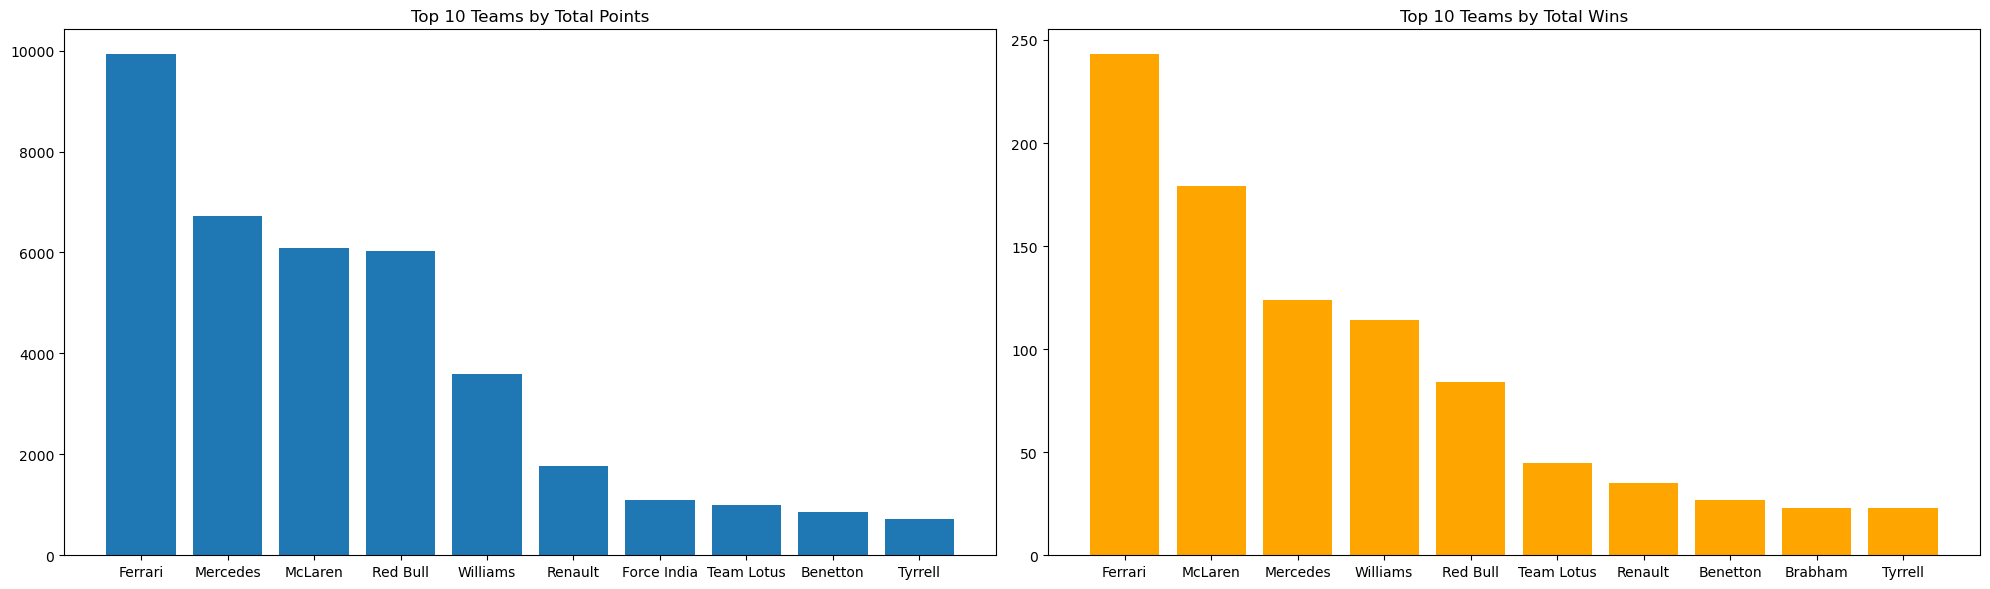

In [20]:
top_points = df_team_summary.sort_values("total_points", ascending=False).head(10)
top_wins = df_team_summary.sort_values("total_wins", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].bar(top_points["name"], top_points["total_points"])
axes[0].set_title("Top 10 Teams by Total Points")

axes[1].bar(top_wins["name"], top_wins["total_wins"], color="orange")
axes[1].set_title("Top 10 Teams by Total Wins")


plt.tight_layout()
plt.show()

## **Top 10 Teams by Total Points** 

##### The left chart ranks Formula 1 constructors based on the total number of championship points they have accumulated across all seasons. Ferrari stands out overwhelmingly as the most successful team in history, with a points total far exceeding every other constructor. Mercedes and McLaren follow in second and third place, reflecting their long periods of dominance in different F1 eras. Red Bull and Williams also appear near the top, consistent with their strong performances during specific competitive periods, such as Red Bull’s 2010–2013 run and Williams’s success in the 1980s and 1990s. The sharp decline after the top three teams indicates a highly skewed distribution.

## **Top 10 Teams by Total Wins**

##### The right chart presents the number of race victories for each constructor. Ferrari again leads by a significant margin, confirming its position as the most historically dominant team not only in points but also in outright race wins. McLaren ranks second in total wins, slightly ahead of Mercedes, although Mercedes holds a much higher average win rate due to its dominance in the hybrid era (2014–2020). Williams and Red Bull follow, reflecting their competitive peaks during different time periods. Notably, some teams such as Lotus and Renault appear in the top ten by wins but much lower in total points, suggesting shorter but highly successful competitive windows. 


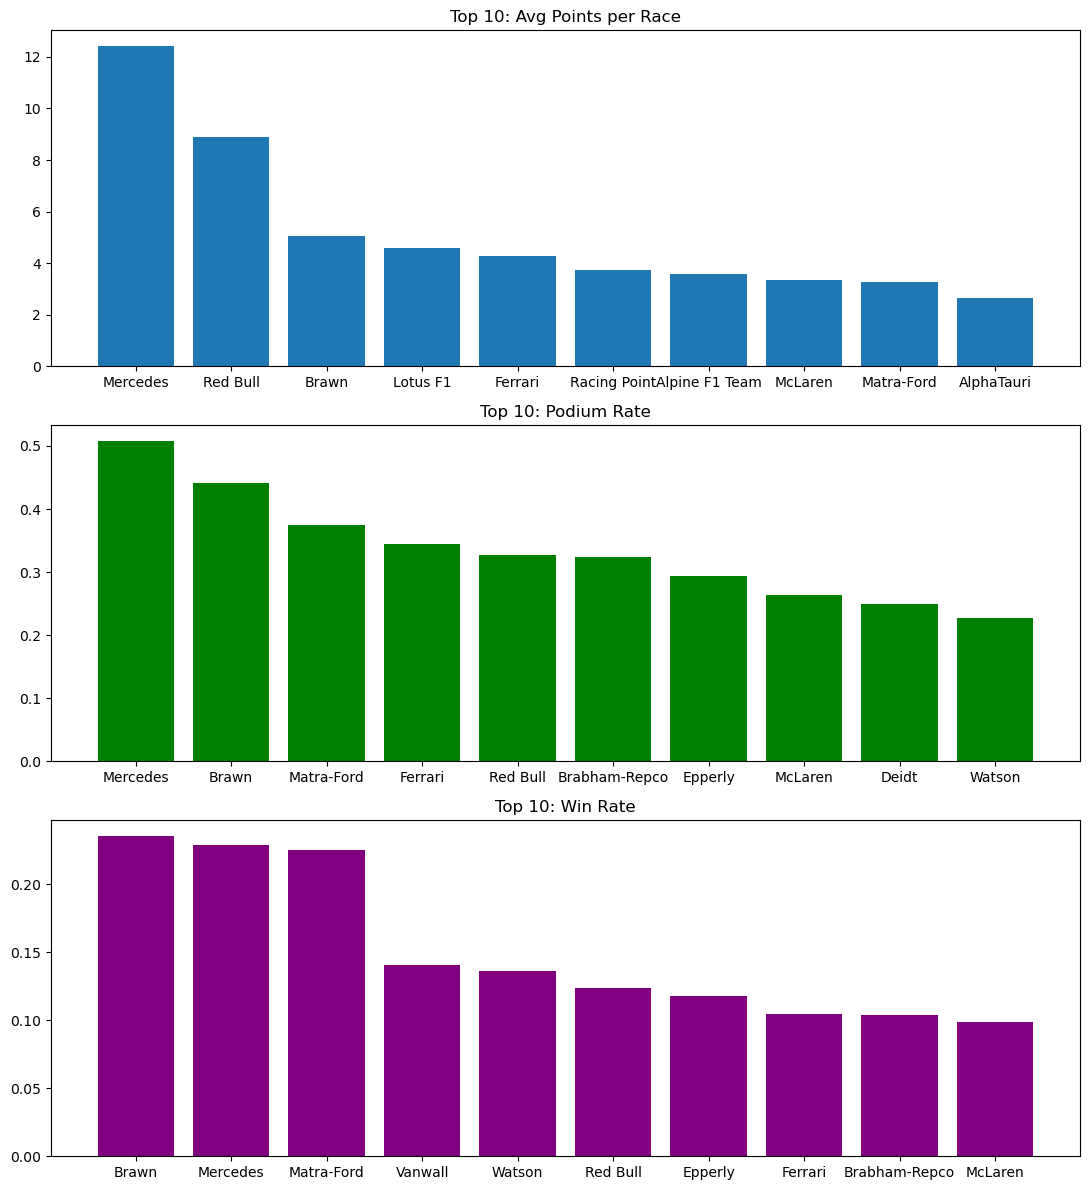

In [19]:
top_avg = df_team_summary.sort_values("points_per_race", ascending=False).head(10)
top_podium = df_team_summary.sort_values("podium_rate", ascending=False).head(10)
top_winrate = df_team_summary.sort_values("win_rate", ascending=False).head(10)

fig, axes = plt.subplots(3, 1, figsize=(11,12))

# Average points per race
axes[0].bar(top_avg["name"], top_avg["points_per_race"])
axes[0].set_title("Top 10: Avg Points per Race")

# Podium rate
axes[1].bar(top_podium["name"], top_podium["podium_rate"], color="green")
axes[1].set_title("Top 10: Podium Rate")

# Win rate
axes[2].bar(top_winrate["name"], top_winrate["win_rate"], color="purple")
axes[2].set_title("Top 10: Win Rate")

plt.tight_layout()
plt.show()


## **Figure 1: Top 10 – Average Points per Race**

##### This figure highlights which constructors sustained long-term dominance.
##### **Mercedes clearly stands far above all teams**, averaging more than 12 points per race, showing its unprecedented control during the hybrid era (2014–2020).  
##### **Red Bull** also performs strongly, maintaining a noticeable lead over the remaining constructors.  Teams like **Brawn, Lotus F1, and Ferrari** demonstrate strong but era-specific performances.  
##### Constructors such as Alpine, McLaren, and Matra-Ford remain competitive but never reach true dominance.

##### Overall, average points per race is the strongest indicator of long-term performance, positioning Mercedes and Red Bull as the two most dominant constructors in modern F1 history.


---

## **Figure 2: Top 10 – Podium Rate**

##### This figure emphasizes consistent competitiveness across races.  
##### **Mercedes again ranks first**, showing not only strong scoring ability but also exceptional consistency in finishing inside the top three.  
##### **Brawn** shows an extremely high podium rate due to its extraordinary but short-lived 2009 season.  
##### **Matra-Ford, Ferrari, and Red Bull** also demonstrate meaningful historical consistency.  
Lower-ranked teams (e.g., Eperly and Deidt) often come from early eras with smaller race counts.

##### Podium rate reveals which teams were reliably competitive, reinforcing Mercedes and Red Bull as the most stable high-performing constructors.


---

## **Figure 3: Top 10 – Win Rate**

##### This figure captures the most decisive metric of dominance: **race victories**.  
##### **Brawn holds the highest win rate**, reflecting its one-year surge of extreme dominance in 2009.  
##### **Mercedes closely follows**, showing sustained championship-level superiority over multiple seasons.  
##### Early-era teams such as **Matra-Ford and Vanwall** achieved high win rates during shorter periods of strong performance.  
##### **Ferrari and Red Bull** show moderate win rates due to long histories that include both dominant and weaker seasons.

##### Win rate highlights peak performance: while Brawn represents short-term dominance, Mercedes is the only constructor with sustained success across multiple eras.

---

##### Across all three metrics—average points, podium rate, and win rate—Mercedes is the most consistently dominant constructor in F1 history**, with Red Bull following as a strong long-term competitor.  
##### Short-term dominant teams (e.g., Brawn, Matra-Ford) appear in individual metrics but do not show sustained performance across eras.


## **Q2. How Does Each Team's Performance Change Over Time?**

In [16]:
tmp = results.copy()
tmp["position"] = pd.to_numeric(tmp["position"], errors="coerce")  # Convert non-numeric values to NaN
tmp["points"]   = pd.to_numeric(tmp["points"], errors="coerce").fillna(0)  # Convert non-numeric values to NaN and fill missing points with 0
tmp["win"] = (tmp["position"] == 1)       # Whether the constructor won the race
tmp["podium"] = (tmp["position"] <= 3)    # Whether the constructor finished on the podium (Top 3)

# 2. Aggregate by constructor: total points, total wins, total podiums, and number of races
summary = (
    tmp.groupby("constructorId")
       .agg(
           total_points  = ("points", "sum"),     # Total points
           total_wins    = ("win", "sum"),        # Total wins
           total_podiums = ("podium", "sum"),     # Total podium finishes
           total_races   = ("raceId", "count")    # Number of races participated
       )
       .reset_index()
)

# 3. Compute rate-based performance metrics
summary["points_per_race"] = summary["total_points"]   / summary["total_races"]
summary["win_rate"]        = summary["total_wins"]     / summary["total_races"]
summary["podium_rate"]     = summary["total_podiums"]  / summary["total_races"]

# 4. Create the final constructor-level dataset with totals and rate metrics
df_team_summary = summary.merge(constructors, on="constructorId", how="left")

display(df_team_summary)
display(df)


,constructorId,total_points,total_wins,total_podiums,total_races,points_per_race,win_rate,podium_rate,name
0,1,6085.5,179,478,1813,3.356591,0.098731,0.263651,McLaren
1,2,308.0,1,17,140,2.200000,0.007143,0.121429,BMW Sauber
2,3,3593.0,114,313,1567,2.292916,0.072750,0.199745,Williams
3,4,1777.0,35,103,787,2.257942,0.044473,0.130877,Renault
4,5,500.0,1,3,536,0.932836,0.001866,0.005597,Toro Rosso
...,...,...,...,...,...,...,...,...,...
205,209,1.0,0,0,78,0.012821,0.000000,0.000000,Manor Marussia
206,210,231.0,0,0,270,0.855556,0.000000,0.000000,Haas F1 Team
207,211,283.0,1,4,76,3.723684,0.013158,0.052632,Racing Point
208,213,276.0,1,2,104,2.653846,0.009615,0.019231,AlphaTauri


,raceId,constructorId,points,position,wins,year,name,era,win,podium
0,18,1,14.0,1,1,2008,McLaren,1990-2013,True,True
1,18,2,8.0,3,0,2008,BMW Sauber,1990-2013,False,True
2,18,3,9.0,2,0,2008,Williams,1990-2013,False,True
3,18,4,5.0,4,0,2008,Renault,1990-2013,False,False
4,18,5,2.0,5,0,2008,Toro Rosso,1990-2013,False,False
...,...,...,...,...,...,...,...,...,...,...
12836,1086,213,27.0,8,0,2022,AlphaTauri,Ground Effect Era (2022- ),False,False
12837,1086,117,20.0,9,0,2022,Aston Martin,Ground Effect Era (2022- ),False,False
12838,1086,3,3.0,10,0,2022,Williams,Ground Effect Era (2022- ),False,False
12839,1086,1,95.0,5,0,2022,McLaren,Ground Effect Era (2022- ),False,False


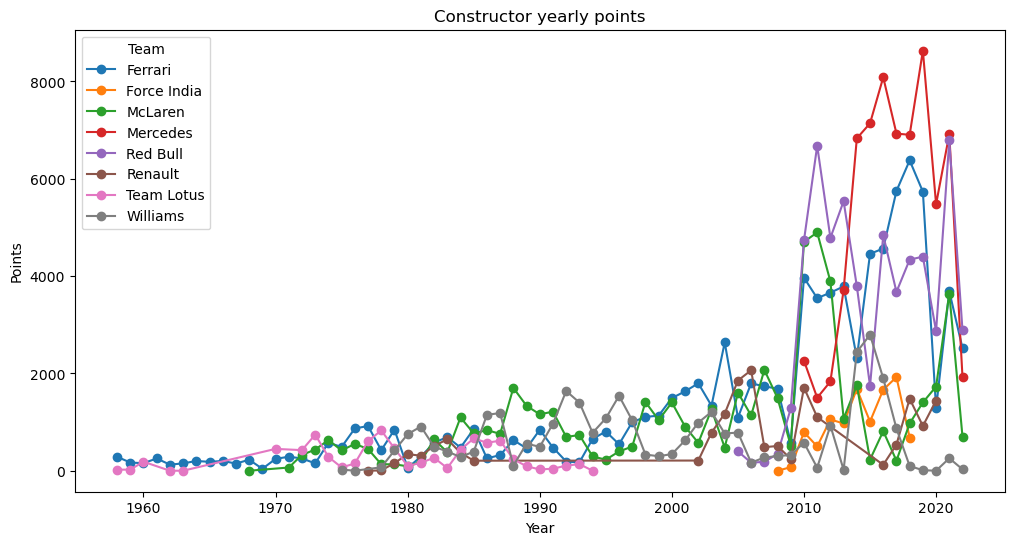

In [17]:

# Yearly constructor totals (points per season)
yearly_points = df.groupby(["year", "name"], as_index=False)["points"].sum()

# Simple line chart (top teams)
top_n = 8  # adjust for more/fewer teams
top_teams = yearly_points.groupby("name")["points"].sum().nlargest(top_n).index
plot_df = yearly_points[yearly_points["name"].isin(top_teams)].sort_values(["name", "year"])

plt.figure(figsize=(12, 6))
for team, g in plot_df.groupby("name"):
    plt.plot(g["year"], g["points"], marker="o", label=team)

plt.title("Constructor yearly points")
plt.xlabel("Year")
plt.ylabel("Points")
plt.legend(title="Team")
plt.show()



#### This plot shows how constructor performance evolves over time. Points remain low and steady before the 2000s due to older scoring systems. After 2010, totals rise sharply as scoring and race counts increase.

#### **Mercedes** shows the clearest modern dominance, with very high and sustained peaks from 2014–2020.  
#### **Red Bull** has two major peaks (early 2010s and 2020s), showing dominance across multiple eras.  
#### **Ferrari, McLaren, and Williams** have strong historical periods but fluctuate more, reflecting cycles rather than continuous dominance.

#### Overall, despite scoring inflation, the plot clearly shows that modern F1 has shifted toward tighter concentration of dominance, led mainly by Mercedes and Red Bull.

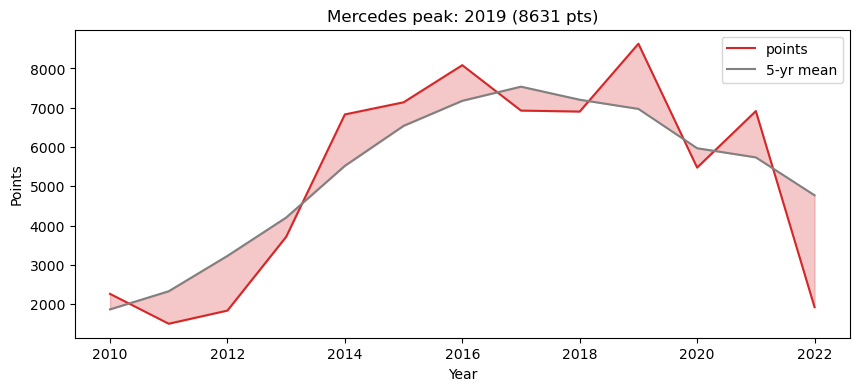

,name,peak_year,peak_points,peak_sharpness
0,Mercedes,2019,8631.0,1660.300
1,Red Bull,2021,6786.5,2552.625
2,Ferrari,2018,6377.0,1634.600
3,McLaren,2011,4896.0,1880.600
4,Lotus F1,2013,3319.0,1447.750
...,...,...,...,...
154,Forti,1995,0.0,0.000
155,Fry,1959,0.0,0.000
156,Gilby,1961,0.0,0.000
157,McLaren-Alfa Romeo,1970,0.0,0.000


In [15]:
# Peak year + sharpness 
window = 5  # centered window for baseline
yearly_points = yearly_points.sort_values(["name", "year"])

# Rolling mean: smooth baseline per constructor over a centered window
yearly_points["rolling_mean"] = (
    yearly_points.groupby("name")["points"]
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

peak_table = yearly_points.loc[yearly_points.groupby("name")['points'].idxmax()].copy()
peak_table = peak_table.rename(columns={"year": "peak_year", "points": "peak_points", "rolling_mean": "rolling_mean_peak"})
peak_table["peak_sharpness"] = peak_table["peak_points"] - peak_table["rolling_mean_peak"]
peak_table = peak_table[["name", "peak_year", "peak_points", "peak_sharpness"]].sort_values(by="peak_points", ascending=False).reset_index(drop=True)

# Visualize a chosen team (defaults to the top peak team)
top_team = peak_table.loc[0, "name"]  # change index to choose another team
g = yearly_points[yearly_points["name"] == top_team].copy()
g_year = g["year"].astype(int)

plt.figure(figsize=(10, 4))
plt.plot(g_year, g["points"], color="tab:red", label="points")
plt.plot(g_year, g["rolling_mean"], color="gray", label=f"{window}-yr mean")
plt.fill_between(g_year, g["rolling_mean"], g["points"], color="tab:red", alpha=0.25)
plt.title(f"{top_team} peak: {int(g.loc[g['points'].idxmax(), 'year'])} ({g['points'].max():.0f} pts)")
plt.xlabel("Year")
plt.ylabel("Points")
plt.legend()
plt.show()

peak_table

#### This plot shows Mercedes’ rise, peak, and decline during the hybrid era.  
#### Points increase rapidly from 2013 onward, reaching an all-time high in **2019 (8631 points)**.  
#### The 5-year moving average closely follows this trend.

#### After 2019, both yearly points and the moving average begin to fall, marking the end of their peak era and the transition toward a more competitive field in the 2020s.

#### Overall, the figure highlights Mercedes’ historically unmatched dominance from 2014 to 2019, followed by a clear downward trajectory after the regulation changes.

---

## **Q3. Constructor Domination**
In this section, we move beyond simply evaluating which teams are the most successful overall and instead investigate a deeper historical question:
Which teams dominated specific eras of Formula 1, and how can we systematically identify these periods of dominance?

,name,era,total_points,total_wins,total_podiums,participation
0,AGS,1980s,14.0,0,0,52
1,AGS,1990-2013,0.0,0,0,32
2,ATS,1960-70s,2.0,0,0,41
3,ATS,1980s,63.0,0,0,75
4,Alfa Romeo,1960-70s,0.0,0,0,21
...,...,...,...,...,...,...
227,Williams,1990-2013,16916.0,62,191,412
228,Williams,Ground Effect Era (2022- ),29.0,0,0,13
229,Williams,Hybrid Era (2014-2021),8364.0,0,27,160
230,Wolf,1960-70s,687.0,1,14,64


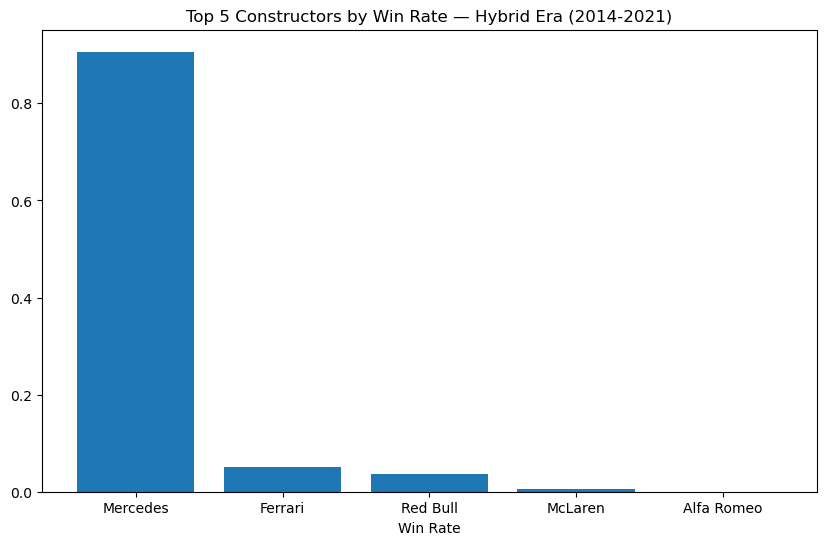

In [14]:
#calculate the final points per constructor per year
def assign_era(year):
    if year < 1960:
        return "1950s"
    elif year < 1980:
        return "1960-70s"
    elif year < 1990:
        return "1980s"
    elif year < 2014:
        return "1990-2013"
    elif year < 2022:
        return "Hybrid Era (2014-2021)"
    else:
        return "Ground Effect Era (2022- )"

df["era"] = df["year"].apply(assign_era)
df["win"] = (df["position"] == 1)
df["podium"] = (df["position"] <= 3)

race_counts = df.groupby(["name", "era"])["raceId"].nunique().reset_index(name="participation")
era_stats = df.groupby(["name", "era"]).agg(
    total_points=("points", "sum"),
    total_wins=("win", "sum"),
    total_podiums=("podium", "sum")
).reset_index()
era_stats = era_stats.merge(race_counts, on=["name", "era"], how="left")
display(era_stats)
era_stats["points_per_race"] = era_stats["total_points"] / era_stats["participation"]
era_stats["win_rate"] = era_stats["total_wins"] / era_stats["participation"]
era_stats["podium_rate"] = era_stats["total_podiums"] / era_stats["participation"]

# Choose one era at a time — example: Hybrid Era (this can be repeated for other eras)
era_subset = era_stats[era_stats["era"] == "Hybrid Era (2014-2021)"]
top5_hybrid = era_subset.sort_values("win_rate", ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.bar(top5_hybrid["name"], top5_hybrid["win_rate"])
plt.title("Top 5 Constructors by Win Rate — Hybrid Era (2014-2021)")
plt.xlabel("Win Rate")
plt.show()


#### This plot highlights the extreme imbalance of competition during the Hybrid Era (2014-2021).
#### Mercedes achieves an extraordinary win rate of over 90%, far surpassing all other constructors in the field.   
#### Ferrari and Red Bull maintain only single-digit win rates, indicatng that they were occasional challengers rather than consistent threats.

#### McLaren and Alfa Remeo remain near 0%, reinforcing the large competitive gap between the leading team and the rest of the grid during this period. 

#### Overall, the figure demonstrates that the Hybrid Era is defined almost entirely by Mercees' overwhelming dominance, establishing one of the most one-sided eras in Formula One history.

---

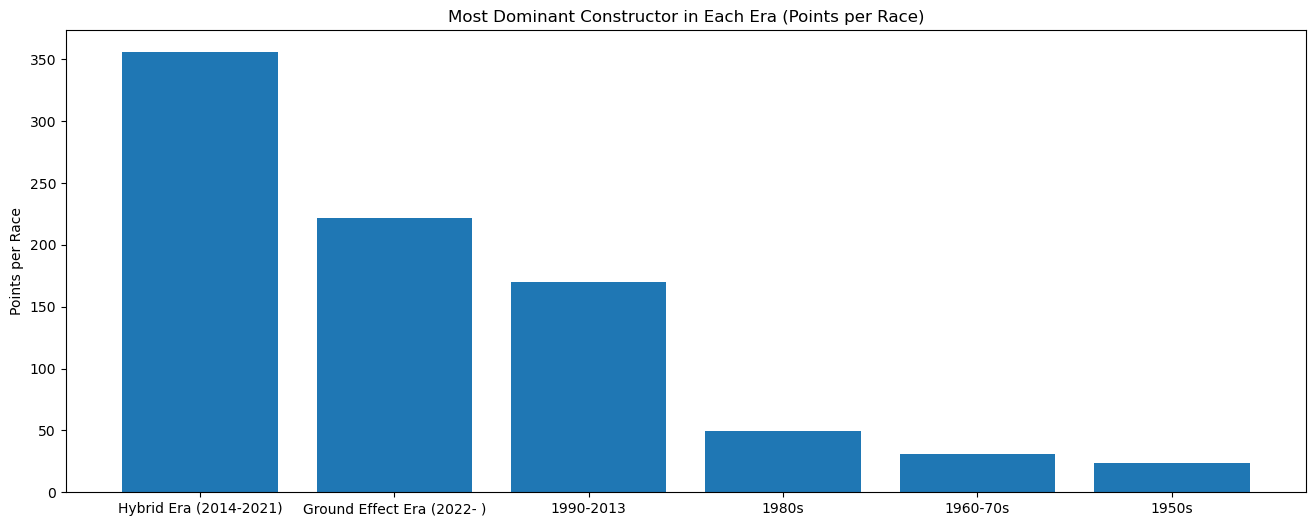

In [15]:
# Compute top constructor per era by points_per_race
best_per_era = era_stats.sort_values("points_per_race", ascending=False).groupby("era").head(1)

plt.figure(figsize=(16,6))
plt.bar(best_per_era["era"], best_per_era["points_per_race"])
plt.title("Most Dominant Constructor in Each Era (Points per Race)")
plt.ylabel("Points per Race")
plt.show()

#### This plot compares the most dominant constructor in each historical era using points per race, a metric that adjusts for differences in race counts across decades.
#### The Hybrid Era (2014-2021) stands out clearly, with the leading constructor scoring over 350 points per race, far above the dominance levels seen in any previous era.   
#### The Ground Effect Era (2022- ) shows the second-highest value, reflecting the strong early performance of Red Bull under the new regulations. 

#### Earlier era - including the 1990-2013 period, the 1980s, the 1960-70s, and the 1950s - display substantially lower points-per-race values, indicating a more competitive field and less concentrated dominance compared with the hybrid era.

#### Overall, the figure highlights how constructor dominance has intensified over time: moden techinical regulations tend to produce clearer performance gap, with the Hybrd Era representing the most extreme example of sustained superiority by a single team in Formula One history.

---

## **Q4. Peak Analysis with Sharpness**
Rolling mean builds a smoothed baseline for each constructor by averaging points over a centered 5-year window; peak sharpness is the gap between the peak season and that baseline (bigger gap = spikier peak).

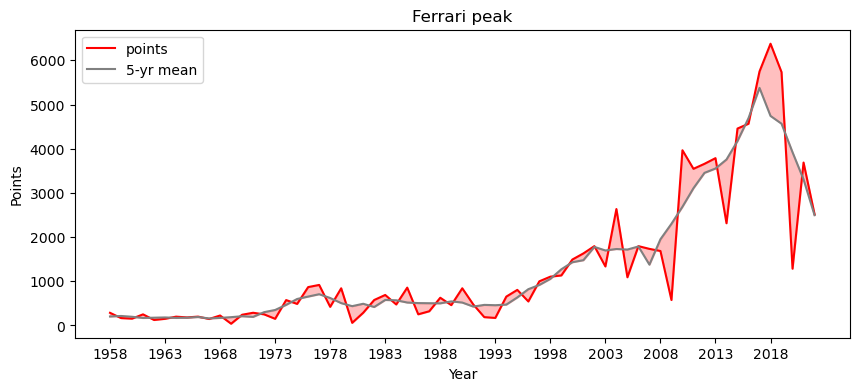

,name,peak_year,peak_points,peak_sharpness
0,Mercedes,2019,8631.0,1660.300
1,Red Bull,2021,6786.5,2552.625
2,Ferrari,2018,6377.0,1634.600
3,McLaren,2011,4896.0,1880.600
4,Lotus F1,2013,3319.0,1447.750
...,...,...,...,...
154,Forti,1995,0.0,0.000
155,Fry,1959,0.0,0.000
156,Gilby,1961,0.0,0.000
157,McLaren-Alfa Romeo,1970,0.0,0.000


In [21]:

# Peak year + sharpness 
window = 5  # centered window for baseline
yearly_points = yearly_points.sort_values(["name", "year"])

# Rolling mean baseline per constructor
yearly_points["rolling_mean"] = (
    yearly_points.groupby("name")["points"]
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

peak_table = yearly_points.loc[yearly_points.groupby("name")["points"].idxmax()]
peak_table = peak_table.rename(columns={
    "year": "peak_year",
    "points": "peak_points",
    "rolling_mean": "rolling_mean_peak"
})
peak_table["peak_sharpness"] = peak_table["peak_points"] - peak_table["rolling_mean_peak"]
peak_table = peak_table[["name", "peak_year", "peak_points", "peak_sharpness"]].sort_values(by="peak_points", ascending=False).reset_index(drop=True)

# Visualize a selected team (change index if you want another)
top_team = peak_table.loc[2, "name"]
g = yearly_points[yearly_points["name"] == top_team].copy()
g_year = g["year"].astype(int)
start, end = g_year.min(), g_year.max()
step = max(1, (end - start) // 12)  # sparse ticks for long histories
x_ticks = list(range(start, end + 1, step))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_year, g["points"], color="red", label="points")
ax.plot(g_year, g["rolling_mean"], color="gray", label=f"{window}-yr mean")
ax.fill_between(g_year, g["rolling_mean"], g["points"], color="red", alpha=0.25)
ax.set_title(f"{top_team} peak")
ax.set_xlabel("Year")
ax.set_ylabel("Points")
ax.set_xticks(x_ticks)
ax.legend()
plt.show()

peak_table


#### This plot illustrates Ferrari's long-term performance tragectory from 1958 to 2022, capturing more than six decades of competitive history. 
#### Ferrari's points begin at modest levels in the early decades and gradually rise through the 1970s and early 1980s, reflecting periods of intermittent success rather than sustained dominance. 
#### A noticeable upward trend emerges in the late 1990s, culminating in the Schumacher era of the early 2000s, where both the yearly points and the 5-year moving average climb sharply. 

#### Ferrari's true statistical peak occurs in 2018 (6377 points), where the red curve reaches its highest value and the moving average also hits a local maximum.

#### Overall, the figure highlights Ferrari's gradual ascent, their early-2000s resurgence, and the decisive peak in 2018- demonstrating how Ferrari's competitiveness has evolved across multiple regulation eras before tapering off again.

---

## **Discussion**

##### Across all analyses, our results reveal clear patterns of how constructor dominance in Formula One has evolved over time. Long-term peak analysis show that Ferrari's competitiveness has risen and fallen across multiple eras, with a modern peak in 2018, while Mecedes exhibits a much sharper and higher peak in 2019, reflecting the height of thier hybrid-era dominance. When examining constructors across the full timeline, scoring levels remain low and relatively flat until the 2000s, after which modern scoring systems and increasing race counts amplify total points. 

#### Even with scoring inflation, the structure of yearly points plot shows that Mecedes (2014-2020) and Red Bull (early 2010s and 2020s) from the clearest periods of concentrated dominance. Rate-based metrics confirm these patterns: Mercedes leads in average points per race and podium rate, while also ranking near the top in win rate, indicating both strategic efficiency and consistent race-winning performance. Red Bull follows as the next strongest modern competitor, while historical teams like Ferrari, McLaren, and Williams demonstrate strong periods but fluctuate more across eras. 

#### Overall, the findings show that Modern F1 has shifted toward sharper, more concentrated dominance cycles, led primarily by **Mercedes** and **Red Bulls** in the past two decades.